# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Harnum Adinda Putri
- **Email:** CDCC229D6X0988@student.devacademy.id
- **ID Dicoding:** CDCC229D6X0988

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren jumlah peminjaman sepeda dari bulan ke bulan selama periode 2011-2012 dan pada musim apa permintaan paling tinggi?
- **Pertanyaan 2:** Bagaimana pengaruh kondisi cuaca dan suhu terhadap jumlah total peminjaman sepeda?
- **Pertanyaan 3:** Pada jam berapa peminjaman sepeda paling tinggi dan apakah terdapat perbedaan pola antara hari kerja dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
# Load dataset
day_df = pd.read_csv('sample_data/day.csv')
hour_df = pd.read_csv('sample_data/hour.csv')

print('=== day.csv ===')
print(f'Shape: {day_df.shape}')
print(day_df.head())

print('\n=== hour.csv ===')
print(f'Shape: {hour_df.shape}')
print(hour_df.head())

=== day.csv ===
Shape: (731, 16)
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  

**Insight:** (Opsional)
- Dataset harian (day.csv) memiliki 731 baris dan dataset per jam (hour.csv) memiliki 17.379 baris, yang menunjukkan data mencakup periode tahun 2011-2012.
- Secara visual, terdapat perbedaan volume yang signifikan antara pengguna terdaftar (registered) dan pengguna biasa (casual), di mana pengguna terdaftar jauh lebih mendominasi total peminjaman harian.

### Assessing Data

#### Identifying data problem

In [ ]:
print('=== Info day_df ===')
day_df.info()
print('\n=== Info hour_df ===')
hour_df.info()

=== Info day_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

=== Info hour_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1

In [ ]:
print('=== Missing Values - day_df ===')
print(day_df.isnull().sum())

print('\n=== Missing Values - hour_df ===')
print(hour_df.isnull().sum())

=== Missing Values - day_df ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Missing Values - hour_df ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
print(f'Duplikat day_df: {day_df.duplicated().sum()}')
print(f'Duplikat hour_df: {hour_df.duplicated().sum()}')

Duplikat day_df: 0
Duplikat hour_df: 0


In [ ]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Mengidentifikasi tipe data setiap kolom menggunakan fungsi info() untuk memastikan kesesuaian format.
- Memeriksa keberadaan data kosong menggunakan isna().sum() dan data duplikat menggunakan duplicated().sum() pada day_df dan hour_df.
- Melakukan peninjauan statistik deskriptif menggunakan describe() untuk melihat ringkasan parameter distribusi data.

**Insight:** (Opsional)
- Tidak ditemukan adanya missing values maupun data duplikat pada kedua file, sehingga dataset dikategorikan bersih secara kualitas jumlah.
- Terdapat ketidakkonsistenan tipe data pada kolom dteday yang terbaca sebagai 'object', sehingga perlu dikonversi menjadi format 'datetime' pada tahap selanjutnya.
- Kolom-kolom kategorikal seperti season, yr, mnth, holiday, weekday, workingday, dan weathersit masih berupa angka (numerik), sehingga perlu diberikan label kategori agar hasil visualisasi data lebih mudah dipahami.
- Nilai pada kolom suhu, kelembapan, dan kecepatan angin sudah berada dalam rentang hasil normalisasi.

### Cleaning Data

#### Fixing Inconsistent Data Types and Categorical Labeling problem

In [ ]:
def clean_bike_data(df):
    df = df.copy()

    # Konversi tipe data
    df['dteday'] = pd.to_datetime(df['dteday'])

    # Mapping label season
    season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
    df['season_label'] = df['season'].map(season_map)

    # Mapping label weathersit
    weather_map = {
        1: 'Clear/Partly Cloudy',
        2: 'Mist/Cloudy',
        3: 'Light Snow/Rain',
        4: 'Heavy Rain/Snow'
    }
    df['weather_label'] = df['weathersit'].map(weather_map)

    # Mapping label yr
    df['year'] = df['yr'].map({0: 2011, 1: 2012})

    # Mapping label workingday
    df['day_type'] = df['workingday'].map({0: 'Hari Libur/Akhir Pekan', 1: 'Hari Kerja'})

    # Denormalisasi temperature (t_min=-8, t_max=+39 derajat Celsius)
    df['temp_celsius'] = df['temp'] * 41 - 8

    # Nama bulan
    month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
    df['month_name'] = df['mnth'].map(month_map)

    return df

day_df = clean_bike_data(day_df)
hour_df = clean_bike_data(hour_df)

print(day_df[['dteday', 'season_label', 'weather_label', 'year', 'day_type', 'temp_celsius']].head())

      dteday season_label        weather_label  year                day_type  \
0 2011-01-01       Spring          Mist/Cloudy  2011  Hari Libur/Akhir Pekan   
1 2011-01-02       Spring          Mist/Cloudy  2011  Hari Libur/Akhir Pekan   
2 2011-01-03       Spring  Clear/Partly Cloudy  2011              Hari Kerja   
3 2011-01-04       Spring  Clear/Partly Cloudy  2011              Hari Kerja   
4 2011-01-05       Spring  Clear/Partly Cloudy  2011              Hari Kerja   

   temp_celsius  
0      6.110847  
1      6.902598  
2      0.050924  
3      0.200000  
4      1.305237  


**Insight:** (Opsional)
- Penggunaan fungsi memastikan konsistensi cleaning data antara dataset harian dan per jam, sehingga mengurangi risiko kesalahan manusia.
- Penambahan kolom label baru, seperti season_label dan weather_label memudahkan proses analisis tanpa menghilangkan data asli.
- Denormalisasi suhu ke dalam satuan Celsius memberikan gambaran cuaca yang lebih akurat dan logis.
- Data awal menunjukkan bahwa suhu rendah, yaitu sekitar 0–6°C pada awal tahun, berkorelasi dengan rendahnya jumlah peminjaman sepeda. Hal ini mengindikasikan bahwa suhu dingin memengaruhi menurunnya minat pengguna.


## Exploratory Data Analysis (EDA)

### Explore day_df and hour_df

In [ ]:
# Tren bulanan
monthly_df = day_df.resample(rule='ME', on='dteday').agg({
    'cnt': 'sum',
    'casual': 'sum',
    'registered': 'sum'
}).reset_index()
monthly_df['year_month'] = monthly_df['dteday'].dt.strftime('%Y-%m')

print('Tren Bulanan Peminjaman Sepeda:')
print(monthly_df[['year_month', 'cnt', 'casual', 'registered']].to_string())

Tren Bulanan Peminjaman Sepeda:
   year_month     cnt  casual  registered
0     2011-01   38189    3073       35116
1     2011-02   48215    6242       41973
2     2011-03   64045   12826       51219
3     2011-04   94870   22346       72524
4     2011-05  135821   31050      104771
5     2011-06  143512   30612      112900
6     2011-07  141341   36452      104889
7     2011-08  136691   28842      107849
8     2011-09  127418   26545      100873
9     2011-10  123511   25222       98289
10    2011-11  102167   15594       86573
11    2011-12   87323    8448       78875
12    2012-01   96744    8969       87775
13    2012-02  103137    8721       94416
14    2012-03  164875   31618      133257
15    2012-04  174224   38456      135768
16    2012-05  195865   44235      151630
17    2012-06  202830   43294      159536
18    2012-07  203607   41705      161902
19    2012-08  214503   43197      171306
20    2012-09  218573   43778      174795
21    2012-10  198841   34538      164303
22

In [ ]:
# Rata-rata per musim
season_avg = day_df.groupby('season_label').agg(
    avg_cnt=('cnt', 'mean'),
    total_cnt=('cnt', 'sum')
).reset_index().sort_values('avg_cnt', ascending=False)

print('Rata-rata Peminjaman per Musim:')
print(season_avg)

Rata-rata Peminjaman per Musim:
  season_label      avg_cnt  total_cnt
0         Fall  5644.303191    1061129
2       Summer  4992.331522     918589
3       Winter  4728.162921     841613
1       Spring  2604.132597     471348


In [ ]:
# Rata-rata peminjaman per kondisi cuaca
weather_avg = day_df.groupby('weather_label').agg(
    avg_cnt=('cnt', 'mean'),
    count=('cnt', 'count')
).reset_index().sort_values('avg_cnt', ascending=False)

print('Rata-rata Peminjaman per Kondisi Cuaca:')
print(weather_avg)

# Korelasi suhu vs peminjaman
corr_temp = day_df['temp'].corr(day_df['cnt'])
print(f'\nKorelasi Suhu vs Peminjaman: {corr_temp:.4f}')

Rata-rata Peminjaman per Kondisi Cuaca:
         weather_label      avg_cnt  count
0  Clear/Partly Cloudy  4876.786177    463
2          Mist/Cloudy  4035.862348    247
1      Light Snow/Rain  1803.285714     21

Korelasi Suhu vs Peminjaman: 0.6275


In [ ]:
# Rata-rata peminjaman per jam, dibagi hari kerja vs libur
hourly_pattern = hour_df.groupby(['hr', 'day_type']).agg(
    avg_cnt=('cnt', 'mean')
).reset_index()

print('Pola Peminjaman Per Jam (5 jam tertinggi - Hari Kerja):')
workday = hourly_pattern[hourly_pattern['day_type']=='Hari Kerja']
print(workday.nlargest(5, 'avg_cnt'))

print('\nPola Peminjaman Per Jam (5 jam tertinggi - Hari Libur):')
holiday = hourly_pattern[hourly_pattern['day_type']=='Hari Libur/Akhir Pekan']
print(holiday.nlargest(5, 'avg_cnt'))

Pola Peminjaman Per Jam (5 jam tertinggi - Hari Kerja):
    hr    day_type     avg_cnt
34  17  Hari Kerja  525.290581
36  18  Hari Kerja  492.226908
16   8  Hari Kerja  477.006048
38  19  Hari Kerja  348.401606
32  16  Hari Kerja  293.122244

Pola Peminjaman Per Jam (5 jam tertinggi - Hari Libur):
    hr                day_type     avg_cnt
27  13  Hari Libur/Akhir Pekan  372.731602
25  12  Hari Libur/Akhir Pekan  366.259740
29  14  Hari Libur/Akhir Pekan  364.645022
31  15  Hari Libur/Akhir Pekan  358.813853
33  16  Hari Libur/Akhir Pekan  352.727273


In [ ]:
print('Statistik Pengguna Casual:')
print(day_df['casual'].describe())

print('\nStatistik Pengguna Registered:')
print(day_df['registered'].describe())

pct_casual = day_df['casual'].sum() / day_df['cnt'].sum() * 100
pct_registered = day_df['registered'].sum() / day_df['cnt'].sum() * 100
print(f'\nProporsi Casual: {pct_casual:.1f}%')
print(f'Proporsi Registered: {pct_registered:.1f}%')

Statistik Pengguna Casual:
count     731.000000
mean      848.176471
std       686.622488
min         2.000000
25%       315.500000
50%       713.000000
75%      1096.000000
max      3410.000000
Name: casual, dtype: float64

Statistik Pengguna Registered:
count     731.000000
mean     3656.172367
std      1560.256377
min        20.000000
25%      2497.000000
50%      3662.000000
75%      4776.500000
max      6946.000000
Name: registered, dtype: float64

Proporsi Casual: 18.8%
Proporsi Registered: 81.2%


**Insight:** (Opsional)
- Pertumbuhan dan Tren Waktu: Terdapat kenaikan volume peminjaman yang sangat signifikan dari tahun 2011 ke 2012. Puncak peminjaman secara konsisten terjadi pada bulan Mei hingga September, sementara titik terendah berada di bulan Januari.
- Faktor Cuaca dan Musim: Musim Fall merupakan musim dengan rata-rata peminjaman tertinggi $5.644$ unit, sedangkan musim Spring adalah yang terendah.
- Korelasi Suhu: Nilai korelasi sebesar 0,6275 menunjukkan adanya hubungan positif yang kuat antara suhu dan jumlah peminjaman, semakin hangat suhu, semakin tinggi juga minat masyarakat untuk bersepeda.
- Perbedaan Perilaku Harian: Pada hari kerja, penggunaan sepeda memuncak pada jam sibuk berangkat dan pulang kantor (08.00 dan 17.00). Sebaliknya, pada hari libur, pengguna lebih aktif di siang hari (jam 12.00 hingga 15.00), yang menunjukkan penggunaan untuk alat rekreasi.
- Dominasi Profil Pengguna: Bisnis ini sangat bergantung pada pengguna terdaftar (registered) yang menyumbang 81,2% dari total peminjaman, sedangkan pengguna biasa (casual) hanya berkontribusi sebesar 18,8%.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

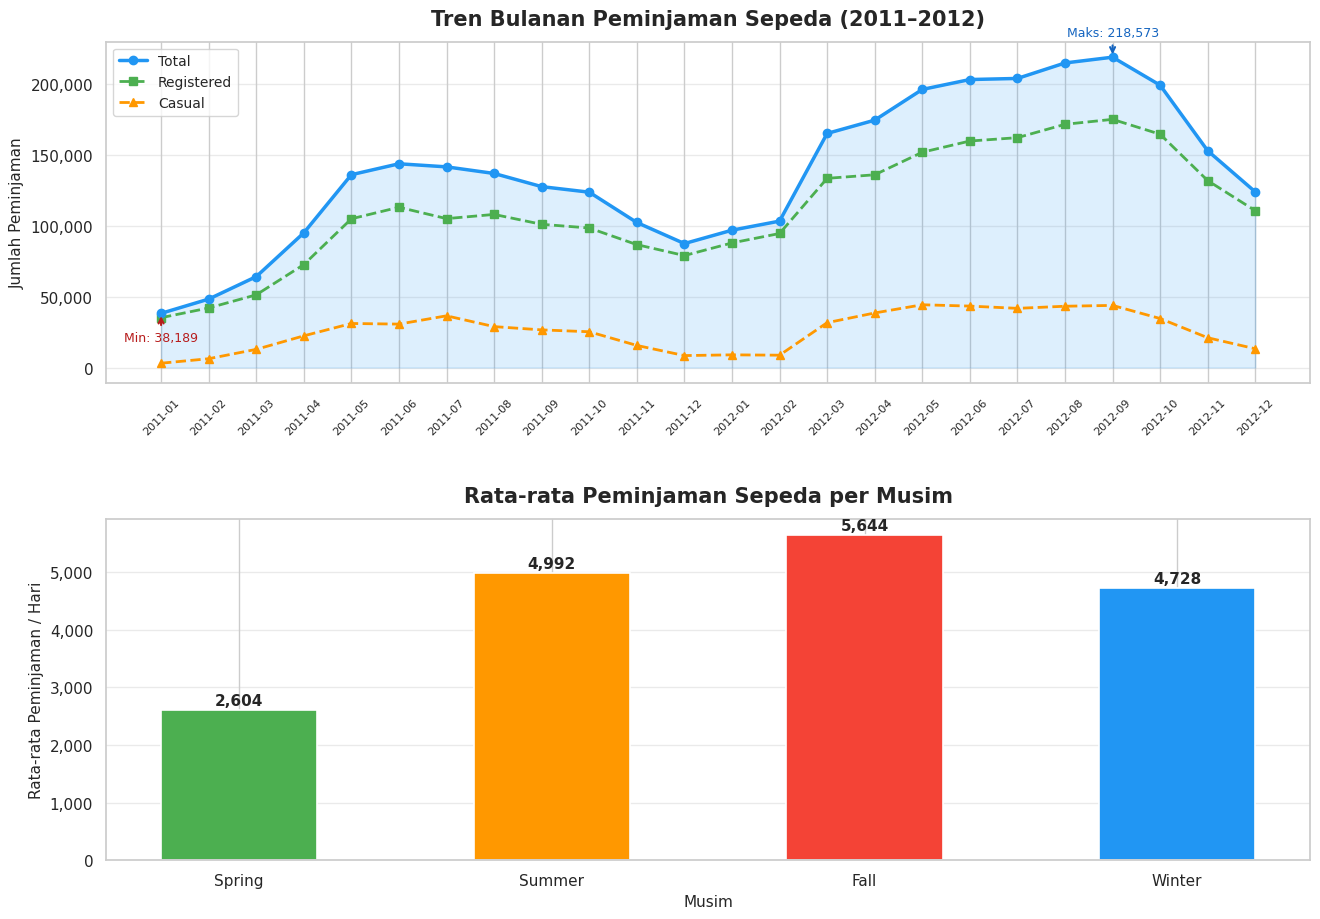

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Plot 1: Tren Bulanan ---
ax1 = axes[0]
ax1.plot(monthly_df['year_month'], monthly_df['cnt'],
         marker='o', linewidth=2.5, color='#2196F3', label='Total', zorder=3)
ax1.fill_between(monthly_df['year_month'], monthly_df['cnt'],
                 alpha=0.15, color='#2196F3')
ax1.plot(monthly_df['year_month'], monthly_df['registered'],
         marker='s', linewidth=2, color='#4CAF50', linestyle='--', label='Registered')
ax1.plot(monthly_df['year_month'], monthly_df['casual'],
         marker='^', linewidth=2, color='#FF9800', linestyle='--', label='Casual')

# Highlight nilai max dan min
max_idx = monthly_df['cnt'].idxmax()
min_idx = monthly_df['cnt'].idxmin()
ax1.annotate(f"Maks: {monthly_df.loc[max_idx, 'cnt']:,}",
             xy=(monthly_df.loc[max_idx, 'year_month'], monthly_df.loc[max_idx, 'cnt']),
             xytext=(0, 15), textcoords='offset points',
             ha='center', fontsize=9, color='#1565C0',
             arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.5))
ax1.annotate(f"Min: {monthly_df.loc[min_idx, 'cnt']:,}",
             xy=(monthly_df.loc[min_idx, 'year_month'], monthly_df.loc[min_idx, 'cnt']),
             xytext=(0, -20), textcoords='offset points',
             ha='center', fontsize=9, color='#B71C1C',
             arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.5))

ax1.set_title('Tren Bulanan Peminjaman Sepeda (2011–2012)', fontsize=15, fontweight='bold', pad=12)
ax1.set_ylabel('Jumlah Peminjaman', fontsize=11)
ax1.legend(fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(axis='y', alpha=0.4)
ax1.set_xlabel('')

# --- Plot 2: Rata-rata per Musim ---
ax2 = axes[1]
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_colors = {'Spring': '#4CAF50', 'Summer': '#FF9800', 'Fall': '#F44336', 'Winter': '#2196F3'}
season_plot = day_df.groupby('season_label')['cnt'].mean().reindex(season_order).reset_index()
season_plot.columns = ['season_label', 'avg_cnt']
bar_colors = [season_colors[s] for s in season_plot['season_label']]
bars = ax2.bar(season_plot['season_label'], season_plot['avg_cnt'],
               color=bar_colors, edgecolor='white', linewidth=1.2, width=0.5)

for bar, val in zip(bars, season_plot['avg_cnt']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_title('Rata-rata Peminjaman Sepeda per Musim', fontsize=15, fontweight='bold', pad=12)
ax2.set_ylabel('Rata-rata Peminjaman / Hari', fontsize=11)
ax2.set_xlabel('Musim', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout(pad=3)
plt.show()

### Pertanyaan 2:

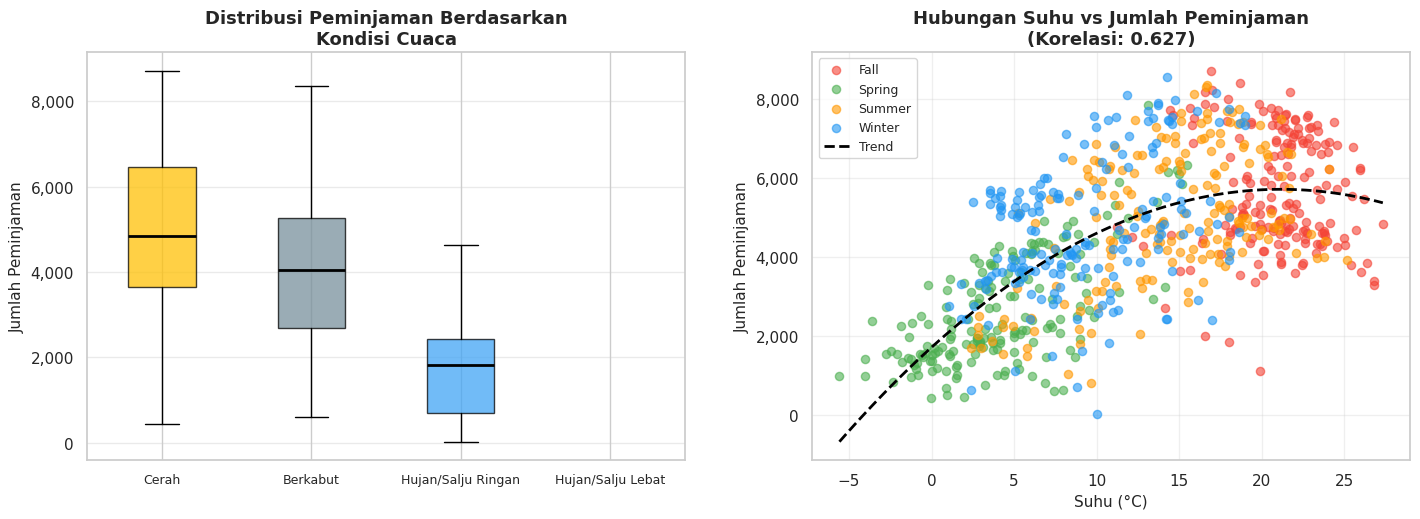

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Boxplot per kondisi cuaca ---
ax1 = axes[0]
weather_order = ['Clear/Partly Cloudy', 'Mist/Cloudy', 'Light Snow/Rain', 'Heavy Rain/Snow']
weather_colors = ['#FFC107', '#78909C', '#42A5F5', '#546E7A']
weather_data = [day_df[day_df['weather_label']==w]['cnt'].values for w in weather_order]
weather_labels_short = ['Cerah', 'Berkabut', 'Hujan/Salju Ringan', 'Hujan/Salju Lebat']

bp = ax1.boxplot(weather_data, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], weather_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax1.set_xticklabels(weather_labels_short, fontsize=9)
ax1.set_title('Distribusi Peminjaman Berdasarkan\nKondisi Cuaca', fontsize=13, fontweight='bold')
ax1.set_ylabel('Jumlah Peminjaman', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(axis='y', alpha=0.4)

# --- Plot 2: Scatter suhu vs peminjaman ---
ax2 = axes[1]
season_palette = {'Spring': '#4CAF50', 'Summer': '#FF9800', 'Fall': '#F44336', 'Winter': '#2196F3'}
for season, group in day_df.groupby('season_label'):
    ax2.scatter(group['temp_celsius'], group['cnt'],
                alpha=0.6, s=35, label=season,
                color=season_palette.get(season, 'gray'))

# Trend line
z = np.polyfit(day_df['temp_celsius'], day_df['cnt'], 2)
p = np.poly1d(z)
x_line = np.linspace(day_df['temp_celsius'].min(), day_df['temp_celsius'].max(), 100)
ax2.plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--', label='Trend')

ax2.set_title(f'Hubungan Suhu vs Jumlah Peminjaman\n(Korelasi: {corr_temp:.3f})',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Suhu (°C)', fontsize=11)
ax2.set_ylabel('Jumlah Peminjaman', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout(pad=3)
plt.show()

### Pertanyaan 3:

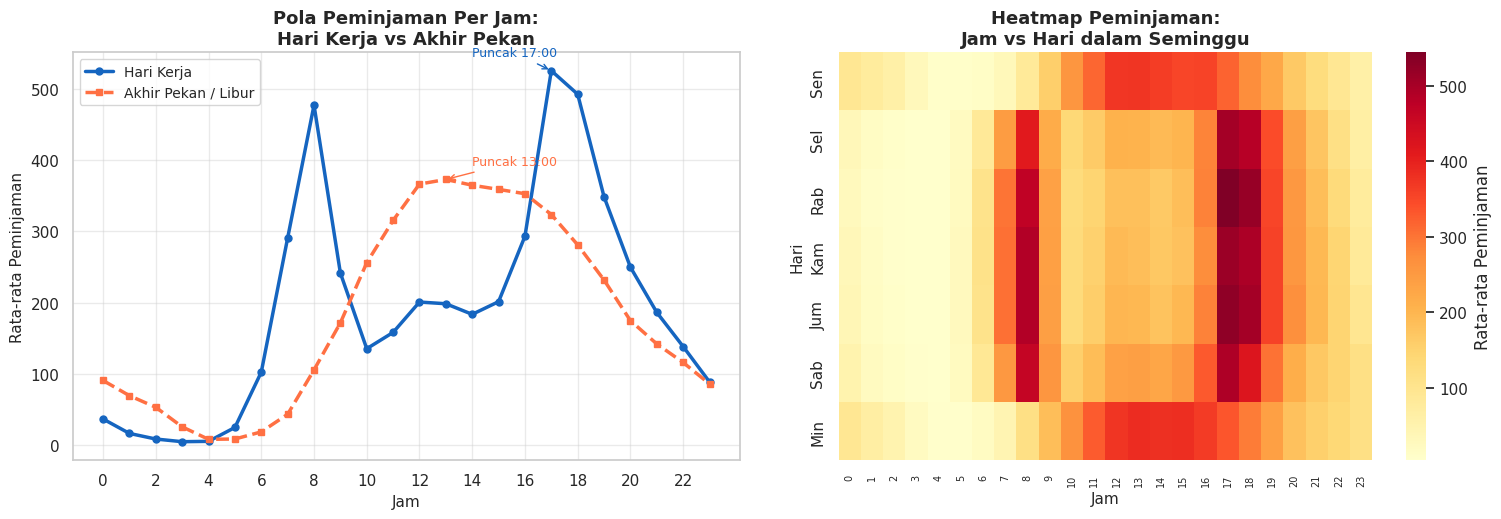

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

workday_hourly = hour_df[hour_df['workingday']==1].groupby('hr')['cnt'].mean()
weekend_hourly = hour_df[hour_df['workingday']==0].groupby('hr')['cnt'].mean()

hours = range(24)

# --- Plot 1: Line chart pola per jam ---
ax1 = axes[0]
ax1.plot(hours, workday_hourly, marker='o', linewidth=2.5, color='#1565C0',
         markersize=5, label='Hari Kerja')
ax1.plot(hours, weekend_hourly, marker='s', linewidth=2.5, color='#FF7043',
         markersize=5, label='Akhir Pekan / Libur', linestyle='--')

# Annotate peaks
peak_work = workday_hourly.idxmax()
peak_wknd = weekend_hourly.idxmax()
ax1.annotate(f'Puncak {peak_work}:00', xy=(peak_work, workday_hourly[peak_work]),
             xytext=(peak_work-3, workday_hourly[peak_work]+20),
             fontsize=9, color='#1565C0',
             arrowprops=dict(arrowstyle='->', color='#1565C0'))
ax1.annotate(f'Puncak {peak_wknd}:00', xy=(peak_wknd, weekend_hourly[peak_wknd]),
             xytext=(peak_wknd+1, weekend_hourly[peak_wknd]+20),
             fontsize=9, color='#FF7043',
             arrowprops=dict(arrowstyle='->', color='#FF7043'))

ax1.set_title('Pola Peminjaman Per Jam:\nHari Kerja vs Akhir Pekan', fontsize=13, fontweight='bold')
ax1.set_xlabel('Jam', fontsize=11)
ax1.set_ylabel('Rata-rata Peminjaman', fontsize=11)
ax1.set_xticks(range(0, 24, 2))
ax1.legend(fontsize=10)
ax1.grid(alpha=0.4)

# --- Plot 2: Heatmap jam x hari ---
ax2 = axes[1]
pivot_data = hour_df.pivot_table(values='cnt', index='weekday', columns='hr', aggfunc='mean')
weekday_labels = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']

sns.heatmap(pivot_data, ax=ax2, cmap='YlOrRd', fmt='.0f',
            xticklabels=range(0, 24), yticklabels=weekday_labels,
            cbar_kws={'label': 'Rata-rata Peminjaman'})
ax2.set_title('Heatmap Peminjaman:\nJam vs Hari dalam Seminggu', fontsize=13, fontweight='bold')
ax2.set_xlabel('Jam', fontsize=11)
ax2.set_ylabel('Hari', fontsize=11)
ax2.tick_params(axis='x', labelsize=7)

plt.tight_layout(pad=3)
plt.show()

**Insight:** (Opsional)
- Pertanyaan 1:
1. Terjadi peningkatan volume peminjaman yang sangat signifikan dari tahun 2011-2012. Hal ini menunjukkan bahwa layanan penyewaan sepeda semakin populer dan diterima oleh masyarakat seiring berjalannya waktu.
2. Grafik menunjukkan bahwa pengguna Registered mendominasi total peminjaman secara konsisten dibandingkan pengguna Casual.
3. Musim Gugur (Fall) adalah periode emas bagi bisnis ini dengan rata-rata tertinggi sebesar 5.644 peminjaman per hari. Kondisi cuaca yang sejuk di musim ini nampaknya menjadi waktu yang paling nyaman bagi pengguna untuk bersepeda. Sebaliknya, Musim Semi (Spring) menunjukkan performa paling rendah dengan rata-rata 2.604 peminjaman per hari. Ini menunjukkan awal musim semi masih cukup dingin, sehingga menghambat minat orang untuk bersepeda.
- Pertanyaan 2:
1. Terdapat penurunan minat yang sangat signifikan seiring dengan memburuknya cuaca.
2. Nilai median tertinggi berada pada cuaca Cerah sekitar 5.000. Kemudian, Penurunan paling drastis terlihat pada cuaca Hujan/Salju Ringan, di mana median peminjaman turun ke angka di bawah 2.000.
3. Grafik scatter menunjukkan hubungan positif yang kuat antara suhu dan jumlah peminjaman. Hal ini terbukti oleh nilai korelasi sebesar 0.627.
- Pertanyaan 3:
1. Pada Hari Kerja, penggunaan sepeda sangat terfokus pada jam sibuk: pagi hari (07:00–09:00) dan sore hari (16:00–19:00). Strategi ketersediaan unit harus difokuskan pada area perkantoran dan stasiun di jam-jam ini.
2. Pada Akhir Pekan/Libur, aktivitas mulai meningkat sejak jam 10:00 pagi dan mencapai puncaknya pada jam 13:00–15:00. Ini menunjukkan penggunaan lebih banyak untuk rekreasi.
3. Warna merah paling pekat terlihat pada hari Selasa, Rabu, dan Kamis sekitar pukul 17.00, yang menunjukkan bahwa pada waktu tersebut sistem penyewaan mengalami beban kerja tertinggi. Sementara itu, pada hari Minggu, intensitas peminjaman cenderung lebih rendah dan tersebar lebih merata sepanjang siang hari dibandingkan hari Sabtu, mencerminkan pola istirahat masyarakat.


## Analisis Lanjutan (Opsional)

### Teknik Analisis Lanjutan: Manual Clustering (Binning)

**Tujuan:**
Tujuan melakukan clustering manual ini adalah untuk mengelompokkan hari-hari berdasarkan total peminjaman sepeda. Hal ini mempermudah bisnis dalam melihat karakteristik hari dengan permintaan rendah, sedang, dan tinggi.

**Cara Kerja:**
Teknik yang digunakan adalah **Binning** menggunakan fungsi `pd.cut()`. Data dikelompokkan berdasarkan nilai persentil dari kolom `cnt` (Total Peminjaman):
1. **Low Demand**: Hari dengan total peminjaman di bawah persentil ke-33 (permintaan rendah).
2. **Medium Demand**: Hari dengan total peminjaman antara persentil ke-33 hingga ke-66 (permintaan sedang).
3. **High Demand**: Hari dengan total peminjaman di atas persentil ke-66 (permintaan tinggi).

Adanya pengelompokan ini, dapat menganalisis perbedaan suhu atau komposisi pengguna (Casual vs Registered) pada setiap kategori permintaan tersebut.

In [32]:
# === Clustering Manual menggunakan Binning ===
# Segmentasi berdasarkan total peminjaman per hari

q1 = day_df['cnt'].quantile(0.33)
q2 = day_df['cnt'].quantile(0.66)
max_cnt = day_df['cnt'].max()
min_cnt = day_df['cnt'].min()

print(f'Q1 (33%): {q1:.0f}')
print(f'Q2 (66%): {q2:.0f}')
print(f'Min: {min_cnt}, Max: {max_cnt}')

# Buat segmen
bins = [min_cnt - 1, q1, q2, max_cnt]
labels = ['Low Demand', 'Medium Demand', 'High Demand']

day_df['demand_segment'] = pd.cut(day_df['cnt'], bins=bins, labels=labels, include_lowest=True)

# Statistik per segmen
segment_stats = day_df.groupby('demand_segment', observed=True).agg(
    jumlah_hari=('cnt', 'count'),
    avg_total=('cnt', 'mean'),
    avg_casual=('casual', 'mean'),
    avg_registered=('registered', 'mean'),
    avg_temp=('temp_celsius', 'mean')
).reset_index()

print('\nStatistik per Segmen Demand:')
print(segment_stats.to_string(index=False))

Q1 (33%): 3716
Q2 (66%): 5266
Min: 22, Max: 8714

Statistik per Segmen Demand:
demand_segment  jumlah_hari   avg_total  avg_casual  avg_registered  avg_temp
    Low Demand          241 2294.439834  331.871369     1962.568465  5.658626
 Medium Demand          241 4492.991701  826.087137     3666.904564 14.800921
   High Demand          249 6654.248996 1369.273092     5284.975904 16.339064


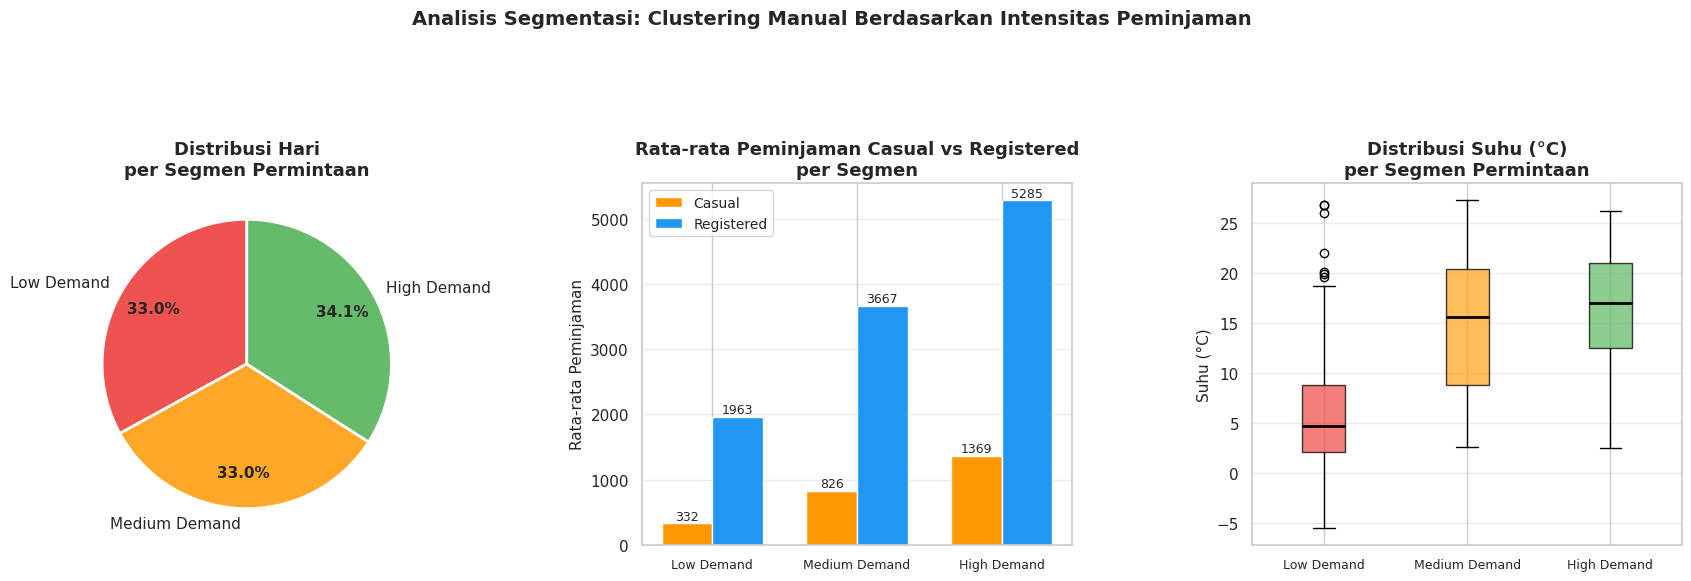

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
seg_colors = ['#EF5350', '#FFA726', '#66BB6A']
seg_labels_short = ['Low Demand', 'Medium Demand', 'High Demand']
segment_stats['label_short'] = seg_labels_short

# --- Plot 1: Jumlah hari per segmen (Pie chart) ---
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    segment_stats['jumlah_hari'],
    labels=seg_labels_short,
    colors=seg_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax1.set_title('Distribusi Hari\nper Segmen Permintaan', fontsize=13, fontweight='bold')

# --- Plot 2: Rata-rata peminjaman casual vs registered per segmen ---
ax2 = axes[1]
x = np.arange(len(seg_labels_short))
w = 0.35
b1 = ax2.bar(x - w/2, segment_stats['avg_casual'], w,
             label='Casual', color='#FF9800', edgecolor='white')
b2 = ax2.bar(x + w/2, segment_stats['avg_registered'], w,
             label='Registered', color='#2196F3', edgecolor='white')
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

ax2.set_title('Rata-rata Peminjaman Casual vs Registered\nper Segmen', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(seg_labels_short, fontsize=9)
ax2.set_ylabel('Rata-rata Peminjaman', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.4)

# --- Plot 3: Karakteristik suhu per segmen ---
ax3 = axes[2]
temp_data = [day_df[day_df['demand_segment']==lbl]['temp_celsius'].values
             for lbl in day_df['demand_segment'].cat.categories]
bp = ax3.boxplot(temp_data, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], seg_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax3.set_xticklabels(seg_labels_short, fontsize=9)
ax3.set_title('Distribusi Suhu (°C)\nper Segmen Permintaan', fontsize=13, fontweight='bold')
ax3.set_ylabel('Suhu (°C)', fontsize=11)
ax3.grid(axis='y', alpha=0.4)

plt.suptitle('Analisis Segmentasi: Clustering Manual Berdasarkan Intensitas Peminjaman',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(pad=3)
plt.show()

**Insight:**
- Data terbagi cukup merata menjadi tiga segmen: **Low Demand (33%)**, **Medium Demand (33%)**, dan **High Demand (34,1%)**.
- **High Demand** berada pada suhu yang lebih hangat.
- Pengguna **Registered** mendominasi semua segmen, namun proporsi **Casual** meningkat secara relatif pada segmen High Demand mengindikasikan hari-hari ramai juga menarik pengguna baru atau wisatawan.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Terjadi pertumbuhan pengguna yang sangat positif. Jumlah peminjaman meningkat drastis dari tahun 2011 ke 2012, dengan puncak tertinggi terjadi pada September 2012. Polanya cenderung naik di tengah tahun dan turun di akhir/awal tahun. Permintaan paling tinggi secara konsisten terjadi pada Musim Gugur (Fall) dengan rata-rata peminjaman mencapai 5.644 per hari, diikuti oleh musim panas.
- **Conclusion pertanyaan 2:**
Cuaca berpengaruh signifikan. Kondisi Cerah/Berawan Sebagian menghasilkan peminjaman tertinggi. Sebaliknya, saat hujan atau salju ringan, jumlah peminjaman merosot tajam. Pada kondisi cuaca ekstrem, aktivitas peminjaman hampir tidak ada. Kemudian, Terdapat korelasi positif yang kuat sebesar 0,627. Artinya, semakin hangat suhu (15°C-25°C), semakin banyak orang yang menyewa sepeda. Namun, jika suhu terlalu panas (di atas 26°C), tren mulai menunjukkan sedikit penurunan.
- **Conclusion pertanyaan 3:** Pada hari kerja grafik memiliki dua puncak. Peminjaman paling tinggi terjadi pada jam sibuk, yaitu pukul 08:00 pagi (berangkat kerja) dan pukul 17:00 sore (pulang kerja). Selanjutnya, pada hari libur/akhir pekan grafik memiliki satu puncak. Peminjaman mulai meningkat perlahan sejak pagi dan mencapai puncaknya pada siang hari, yaitu sekitar pukul 13:00 hingga 15:00 yang menunjukkan penggunaan untuk rekreasi.

**Rekomendasi Action Item:**
- Lakukan perawatan unit sepeda pada jam 00:00 - 04:00 karena intensitas penggunaan paling rendah.
- Berikan promo khusus pada Musim Semi (Spring) karena musim tersebut memiliki performa terendah meskipun kondisi cuaca mulai membaik.
- Pastikan distribusi sepeda maksimal di area perkantoran pada hari kerja sebelum jam 08:00 pagi dan jam 17:00 sore.

In [35]:
day_df.to_csv('main_data.csv', index=False)

In [36]:
hour_df.to_csv("hour_data.csv", index=False)